In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anishpai/ames-housing-dataset-missing/DataDesc.txt
/kaggle/input/datasets/anishpai/ames-housing-dataset-missing/TrainData.csv
/kaggle/input/datasets/anishpai/ames-housing-dataset-missing/TestData.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split      # Split data into training and testing sets
from sklearn.linear_model import LinearRegression         # Build the regression model
from sklearn.metrics import mean_squared_error, r2_score  # Evaluate the model

In [5]:
# LOADING DATASET

df = pd.read_csv("/kaggle/input/datasets/anishpai/ames-housing-dataset-missing/TrainData.csv")

df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.176370,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.433457,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
#  Check for Missing Values

df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 80, dtype: int64

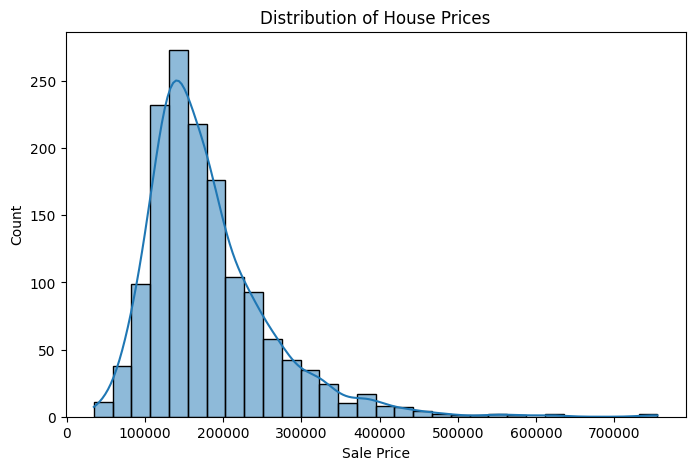

In [7]:
# Target Variable Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

## OBSERVATION

__The distribution of SalePrice is right-skewed, indicating that most houses are priced in the lower to middle range, with fewer high-priced houses.__

## Feature Selection

The following features are expected to have a strong influence on house prices:

OverallQual – Houses with better overall quality generally sell at higher prices.

GrLivArea – Larger living area usually increases the house price.

GarageCars – Houses with larger garages are generally more valuable.

GarageArea – Bigger garage area often contributes to higher prices.

TotalBsmtSF – Larger basement size adds value to the property.

1stFlrSF – Larger first floor area usually increases house value.

YearBuilt – Newer houses often command higher prices.

FullBath – More bathrooms generally improve house value.

Neighborhood – Location is one of the strongest factors affecting house prices.

Reasoning: These features describe the size, quality, age, amenities, and location of a house, all of which directly influence market value.

In [8]:
# Handle Missing Values

# Check percentage of missing values

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageQual        81
GarageType        81
GarageFinish      81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtFinType1      37
BsmtQual          37
BsmtCond          37
dtype: int64

In [9]:
# fill missing values

# Separate numerical and categorical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns

In [10]:
# Fill numerical missing values with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [11]:
# Fill categorical missing values with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
# One-Hot Encode Categorical Variables

df = pd.get_dummies(df, drop_first=True)

df.shape

(1460, 245)

## One-Hot Encoding

Most Machine Learning algorithms, including Linear Regression, require numerical input features. However, this dataset contains several categorical variables (such as Neighborhood, HouseStyle, RoofStyle, etc.) represented as text.

To make these features usable by the model, **One-Hot Encoding** was applied using `pd.get_dummies()`.

Each category is converted into a separate binary (0 or 1) column, allowing the model to interpret categorical information without assuming any ordinal relationship between categories.

The parameter `drop_first=True` was used to remove one category from each feature, helping to avoid multicollinearity (also known as the dummy variable trap), which can negatively affect Linear Regression models.

**Outcome:**
- All categorical (`object`) columns were converted into numerical features.
- The dataset is now ready for correlation analysis and model training.

In [14]:
# verification

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 245 entries, Id to SaleCondition_Partial
dtypes: bool(207), float64(11), int64(27)
memory usage: 728.7 KB


### Observation

After applying One-Hot Encoding, all categorical variables were successfully converted into numerical columns. No `object` datatype columns remain in the dataset, making the data suitable for training the Linear Regression model.

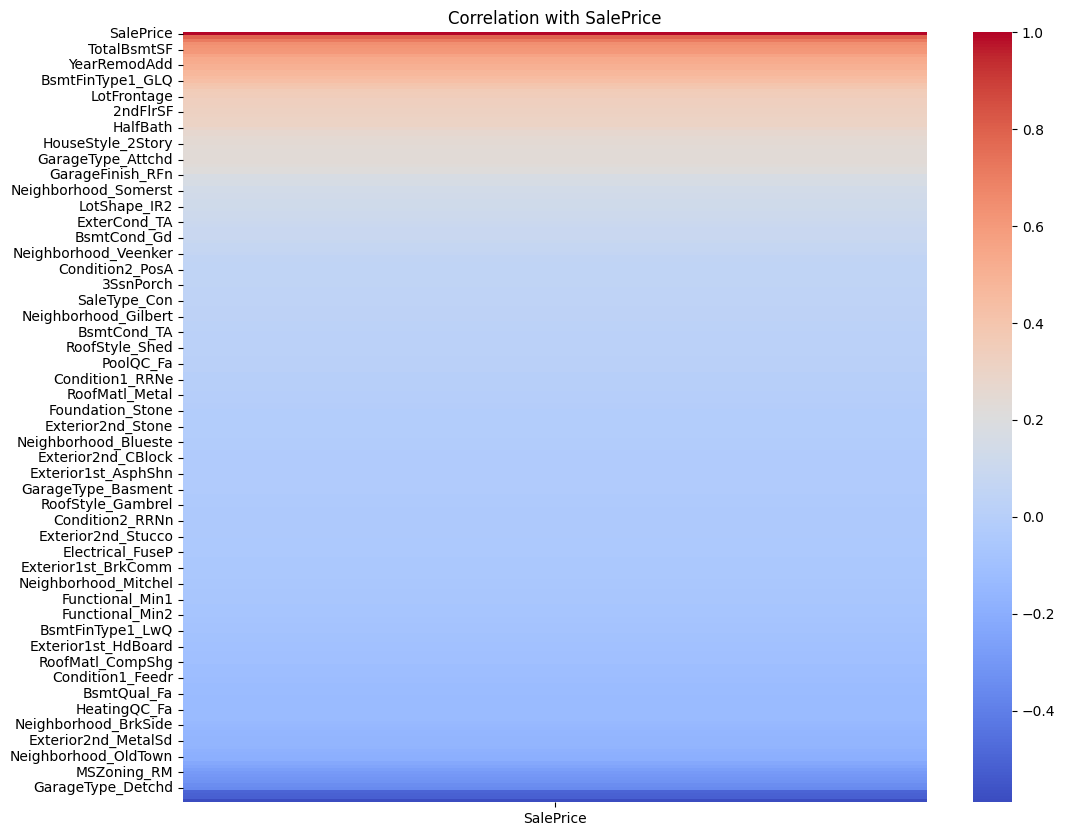

In [15]:
# Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr[['SalePrice']].sort_values(by='SalePrice',
                                            ascending=False),
            annot=False,
            cmap='coolwarm')

plt.title("Correlation with SalePrice")
plt.show()

### Observation

The heatmap shows the relationship between each feature and SalePrice.

Features with correlation values closer to +1 have a strong positive relationship with house prices.

Features with values closer to 0 have little influence on price.

These highly correlated features are likely to be important predictors in the Linear Regression model.

In [16]:
# Find Features Most Correlated with SalePrice

corr["SalePrice"].sort_values(ascending=False).head(15)

SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.708624
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
FullBath            0.560664
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
YearRemodAdd        0.507101
Foundation_PConc    0.497734
MasVnrArea          0.472614
Fireplaces          0.466929
ExterQual_Gd        0.452466
Name: SalePrice, dtype: float64

## Observation

The features with the highest positive correlation with **SalePrice** are the strongest predictors of house prices.

Examples include:

- Overall Quality
- Above Ground Living Area
- Garage Capacity
- Basement Area
- First Floor Area

These features are expected to contribute significantly to the Linear Regression model.

# Feature Selection

The following features are expected to have a strong influence on house prices:

- **OverallQual** – Houses with better overall construction and finish quality generally have higher prices.
- **GrLivArea** – Larger living areas typically increase the value of a house.
- **GarageCars** – Houses with larger garage capacity are often more valuable.
- **GarageArea** – Larger garages contribute positively to house prices.
- **TotalBsmtSF** – A larger basement provides additional usable space and increases value.
- **YearBuilt** – Newer houses generally have higher market values due to modern construction and lower maintenance requirements.

Categorical variables such as **Neighborhood**, **HouseStyle**, and **Exterior Quality** may also influence house prices. These were converted into numerical features using One-Hot Encoding so that they can be used by the Linear Regression model.

In [17]:
# Train-Test Split (80/20)

# Separate Features and Target

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print(X.shape)
print(y.shape)

# spliting data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check the shapes
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

(1460, 244)
(1460,)
Training Features : (1168, 244)
Testing Features  : (292, 244)
Training Labels   : (1168,)
Testing Labels    : (292,)


# Train-Test Split

The dataset was divided into training and testing sets using an **80:20 ratio**.

- **Training Set (80%)** is used to train the Linear Regression model.
- **Testing Set (20%)** is used to evaluate the model's performance on unseen data.

The parameter `random_state=42` ensures that the split is reproducible, meaning the same train-test division is obtained each time the code is executed.

In [18]:
# Train the Linear Regression Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# Training the Linear Regression Model

A **Linear Regression** model was trained using the training dataset.

The `fit()` method learns the relationship between the input features and the target variable (`SalePrice`) by estimating the best-fit coefficients that minimize prediction error.

Once trained, the model can predict house prices for unseen data.

In [19]:
# Predict House Prices

y_pred = model.predict(X_test)

y_pred[:10]

array([156275.66672607, 348946.8817399 ,  85862.48073187, 175750.27909192,
       317438.43595961,  71421.37584648, 235716.91976847, 145772.82473285,
        61776.04337584, 151894.30589593])

# House Price Prediction

The trained Linear Regression model was used to predict house prices for the testing dataset using the `predict()` method.

The predicted values are stored in `y_pred`, which will be compared with the actual house prices to evaluate the model's performance.

In [20]:
# Evaluate the Model

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 2628175164.3237357
Root Mean Squared Error (RMSE): 51265.73089622088
R² Score: 0.6573580975133593


# Model Evaluation

The Linear Regression model was evaluated using three standard regression metrics:

- **Mean Squared Error (MSE):** Measures the average squared prediction error. Lower values indicate better performance.
- **Root Mean Squared Error (RMSE):** Represents the average prediction error in the same unit as the target variable (house price).
- **R² Score:** Indicates how well the model explains the variation in house prices. Values closer to **1** represent better model performance.

These metrics help determine the accuracy and reliability of the trained model.

## Model Evaluation Results

The Linear Regression model achieved the following results:

- **Mean Squared Error (MSE):** 2,628,175,164.32
- **Root Mean Squared Error (RMSE):** 51,265.73
- **R² Score:** 0.657

The model explains approximately **65.7%** of the variation in house prices. While the model captures a significant portion of the relationship between the features and the target variable, there is still room for improvement. More advanced models or additional feature engineering may improve prediction accuracy.

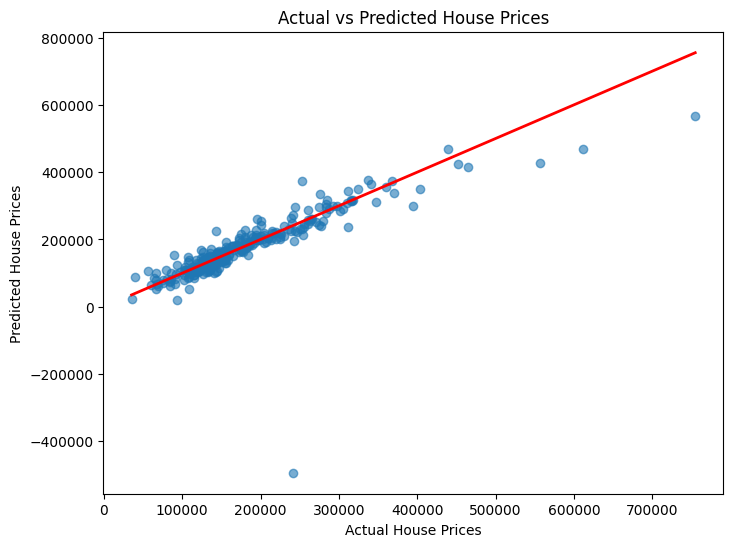

In [21]:
# Actual vs Predicted Prices (Scatter Plot)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.show()

## Actual vs Predicted House Prices

The scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

If the predictions were perfect, all data points would lie exactly on the red diagonal line. The spread of the points around the line indicates the prediction error. Most points are reasonably close to the diagonal, suggesting that the model captures the overall trend but still makes noticeable errors for some houses.

### Observation

The Actual vs Predicted scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

Most data points lie close to the diagonal reference line, indicating that the model predicts house prices reasonably well. A few houses deviate noticeably from the line, suggesting larger prediction errors for some properties, especially higher-priced houses.

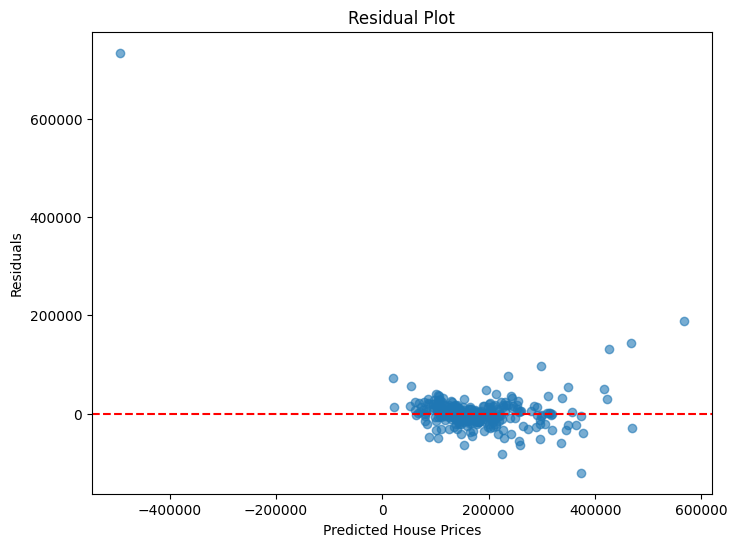

In [22]:
# Residual Plot: Actual Price − Predicted Price

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Residual Plot

The residual plot displays the prediction errors of the model.

A good Linear Regression model produces residuals that are randomly scattered around zero without any clear pattern. This suggests that the model does not systematically overestimate or underestimate house prices.

The residual plot is useful for checking whether the assumptions of Linear Regression are reasonably satisfied.

### Observation

The residual plot shows that most residuals are randomly scattered around zero, indicating that the Linear Regression model captures the general relationship in the data.

A few large residuals exist, representing houses where the prediction error is relatively high. Overall, no strong systematic pattern is observed, suggesting that the assumptions of Linear Regression are reasonably satisfied.

In [23]:
# Coefficient Analysis

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient
112,RoofMatl_Metal,700400.530626
116,RoofMatl_WdShngl,662518.316930
114,RoofMatl_Tar&Grv,656657.671782
113,RoofMatl_Roll,653123.644933
115,RoofMatl_WdShake,651503.114941
110,RoofMatl_CompShg,650909.675785
220,GarageCond_TA,160365.374912
218,GarageCond_Gd,159892.447957
217,GarageCond_Fa,157671.077507
219,GarageCond_Po,157310.525345


## Coefficient Analysis

The Linear Regression model assigns a coefficient to every feature.

Positive coefficients indicate that the feature increases the predicted house price, while negative coefficients indicate a decrease relative to the reference category.

After One-Hot Encoding, categorical variables such as roof material, garage quality, and pool quality are converted into binary columns. Therefore, each coefficient represents the effect of belonging to that category compared with the baseline category.

The model shows that several roof material categories and garage condition categories have the largest positive influence on house prices. On the other hand, features related to poor garage quality, pool quality, and certain property conditions have the largest negative coefficients.

It is important to note that negative coefficients for some "good" categories are a result of One-Hot Encoding and the reference category used during model training. They do not necessarily imply that the feature itself decreases the house price.

In [24]:
coefficients.tail(10)

,Feature,Coefficient
123,Exterior1st_ImStucc,-44704.344018
200,Functional_Sev,-65527.098236
224,PoolQC_Gd,-75769.475366
91,Condition2_RRAe,-97015.657706
223,PoolQC_Fa,-99325.627893
216,GarageQual_TA,-164810.260811
214,GarageQual_Gd,-167219.777595
213,GarageQual_Fa,-169324.053021
215,GarageQual_Po,-181762.072013
90,Condition2_PosN,-237077.637447
